# Tarea PAS. Ignacio Manuel Santos Vendoiro

In [244]:
#Comenzamos cargando las librerias necesarias
import numpy as np
import matplotlib.pyplot as plt

## Elaboracion de la funcion PAS
El siguiente bloque de codigo trata de definir una funcion que dados los parametros:
- p: la probabilidad de tomar el valor 1 en cada paso;
- n: numeros de pasos a simular en cada trayectoria;
- reps: numero de trauectorias a simular;
genera una matriz $reps\times n$ que consiste en si el PAS aumenta o resta 1 en ese paso. Asi, devolvemos una matriz con la suma de las previas columnas en el que cada fila representa una trayectoria distinta

In [245]:
def simular_PAS(p,n,reps):
  
  reps_aux= np.random.binomial(1,p,size=(reps,n))*2-1  # Esta es la matriz auxiliar generada aleatoriamente mediante una funcion que nos devuelve 0,1 segun una binomial B(1,p), multiplicando por 2 y restando uno los transformamos en 1 y -1
  
  # Procedemos a generar la matriz output, que consiste en que cada columna es la suma de las previas de reps_aux
  output=np.cumsum(reps_aux, axis=1)    # (reps, n)


  return output # Shape: (reps, n)

## Visualizacion 1
Procedemos ahora a representar la funcion elaborada para los distintos valores pedidos

[[ -1   0   1 ... -20 -21 -22]
 [  1   2   1 ... -22 -21 -20]
 [ -1   0   1 ...  -4  -5  -4]
 [  1   2   3 ...   4   5   4]
 [  1   2   3 ... -10  -9  -8]]


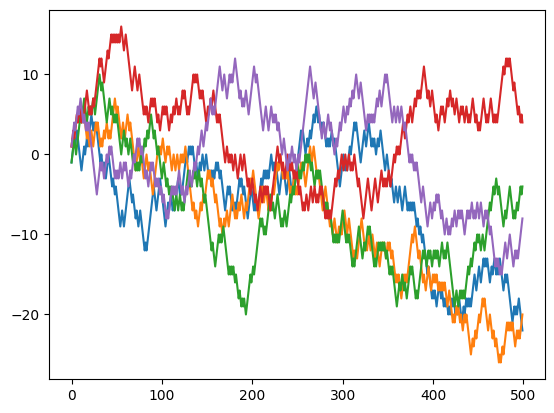

In [246]:
#p=0.5, n=500, reps=5
output_1=simular_PAS(0.5,500,5) 
print(output_1)

#dibujo de las graficas
plt.plot(output_1.T)
plt.show()

[[ -1   0   1 ...  96  97  96]
 [  1   2   1 ... 102 103 102]
 [  1   0   1 ...  76  75  76]
 [  1   0   1 ...  88  89  90]
 [ -1  -2  -1 ...  94  95  94]]


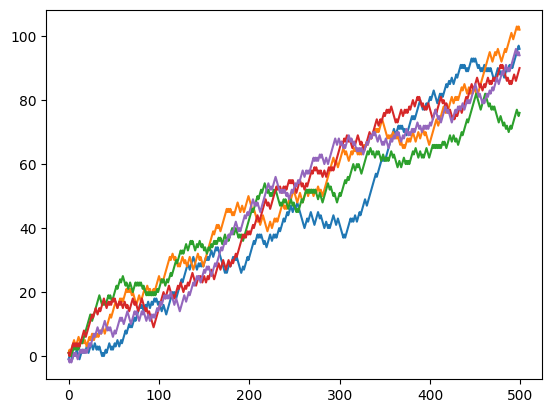

In [247]:
#p=0.6, n=500, reps=5
output_2=simular_PAS(0.6,500,5) 
print(output_2)

plt.plot(output_2.T)
plt.show()

[[  -1    0   -1 ...  -90  -89  -88]
 [  -1    0   -1 ...  -88  -87  -88]
 [   1    0   -1 ...  -58  -57  -58]
 [  -1   -2   -3 ... -100  -99 -100]
 [  -1    0    1 ...  -82  -83  -84]]


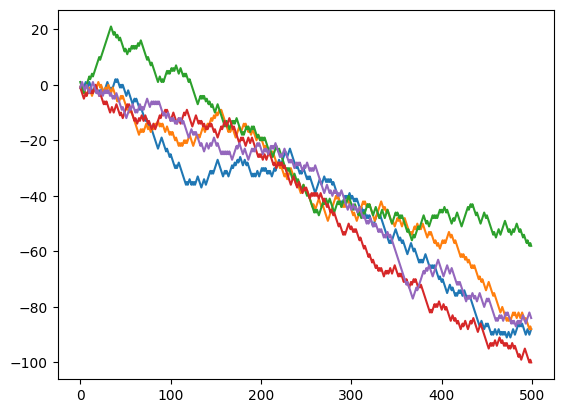

In [248]:
#p=0.4, n=500, reps=5
output_3=simular_PAS(0.4,500,5) 
print(output_3)

plt.plot(output_3.T)
plt.show()

## Visualizacion 2
Este dibujo consiste en lo mismo pero con 20 trayectorias y poniendo sobre la gráfica la media teorica y las desviaciones estandar $\pm 1$.

In [249]:
# Definimos una funcion que calcule la media teórica
def media_teo(n,p):
    output= (2*p-1)*n 
    return output

# Y una que calcule la desviación estandar teórica

def std_teo(n,p):
    output=np.sqrt(4*p*(1-p)*n)
    return output

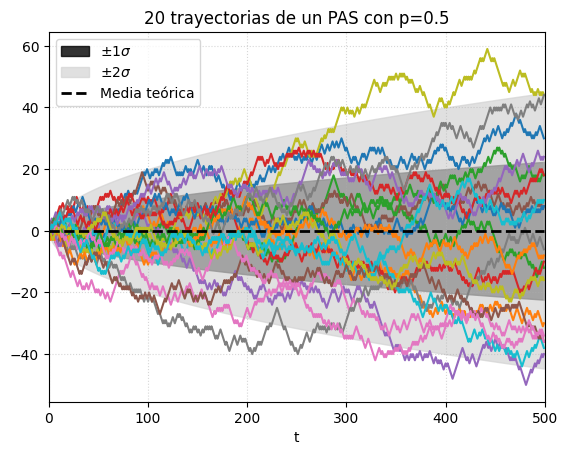

In [250]:
# Definimos los parametros
n=500
p=0.5
reps=20
 

t=np.arange(n)  # este array fila nos servirá para representar graficamente la media  y calcularla teoricamente
output_teo_1=simular_PAS(p,n,20)
media=np.full(n,media_teo(t,p))
desv=np.full(n,std_teo(t,p))


plt.plot(output_teo_1.T)

# Los comandos fill_between son los que pintan las areas grises
plt.fill_between(t, media - desv, media + desv, 
                 color='black', alpha=0.8, label='$\\pm 1\\sigma$')
plt.fill_between(t, media - 2*desv, media + 2*desv, 
                 color='lightgray', alpha=0.7, label='$\\pm 2\\sigma$')
plt.plot(t, media, color='black', linestyle='--', linewidth=2, label='Media teórica')

# Decoramos las graficas
plt.title('20 trayectorias de un PAS con p=0.5')
plt.xlabel('t')
plt.xlim(0, n)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

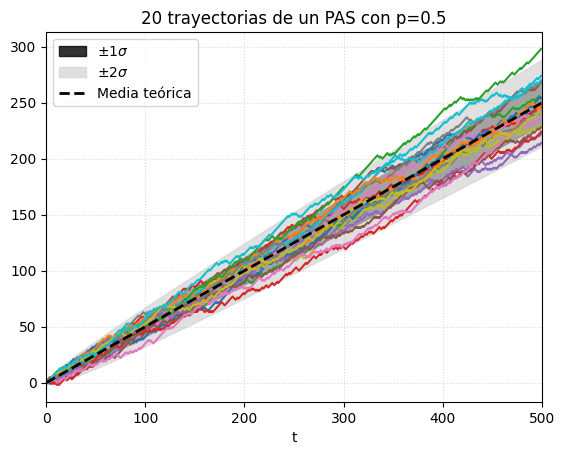

In [251]:
n=500
p=0.75
reps=20

t=np.arange(n)
output_teo_2=simular_PAS(p,n,20)
media=np.full(n,media_teo(t,p))
desv=np.full(n,std_teo(t,p))


plt.plot(output_teo_2.T)

plt.fill_between(t, media - desv, media + desv, 
                 color='black', alpha=0.8, label='$\\pm 1\\sigma$')
plt.fill_between(t, media - 2*desv, media + 2*desv, 
                 color='lightgray', alpha=0.7, label='$\\pm 2\\sigma$')
plt.plot(t, media, color='black', linestyle='--', linewidth=2, label='Media teórica')

plt.title('20 trayectorias de un PAS con p=0.5')
plt.xlabel('t')
plt.xlim(0, n)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

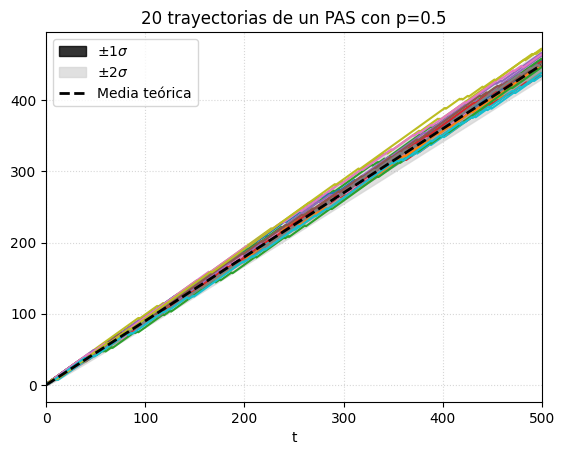

In [252]:
n=500
p=0.95
reps=20

t=np.arange(n)
output_teo_3=simular_PAS(p,n,20)
media=np.full(n,media_teo(t,p))
desv=np.full(n,std_teo(t,p))


plt.plot(output_teo_3.T)
plt.fill_between(t, media - desv, media + desv, 
                 color='black', alpha=0.8, label='$\\pm 1\\sigma$')
plt.fill_between(t, media - 2*desv, media + 2*desv, 
                 color='lightgray', alpha=0.7, label='$\\pm 2\\sigma$')
plt.plot(t, media, color='black', linestyle='--', linewidth=2, label='Media teórica')


plt.title('20 trayectorias de un PAS con p=0.5')
plt.xlabel('t')
plt.xlim(0, n)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

## Visualizacion 3 
Vamos a graficar la media exacta frente a la media empírica obtenida al realizar las simulaciones. Comenzamos realizando una funcion que calcule la media empirica por columnas de un array.


In [253]:
def media_empirica(A):
    output= np.mean(A,axis=0)
    return output

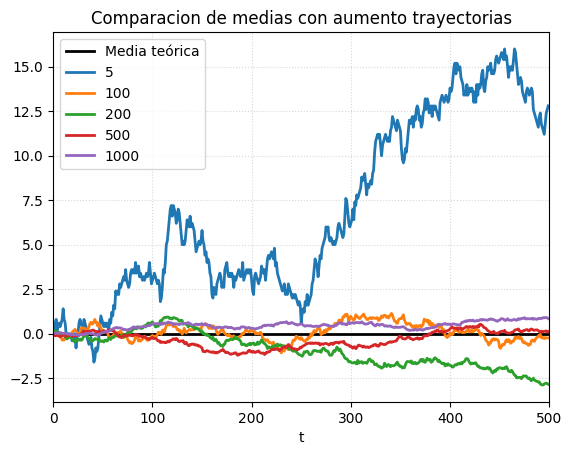

In [254]:
output_media_1=simular_PAS(0.5,500,5)
output_media_2=simular_PAS(0.5,500,100)
output_media_3=simular_PAS(0.5,500,200)
output_media_4=simular_PAS(0.5,500,500)
output_media_5=simular_PAS(0.5,500,1000)

t=np.arange(n)
media=np.full(500,media_teo(t,0.5))

plt.plot(t, media, color= 'black' ,linestyle='-', linewidth=2, label='Media teórica')
plt.plot(t, media_empirica(output_media_1), linestyle='-', linewidth=2, label='5')
plt.plot(t, media_empirica(output_media_2), linestyle='-', linewidth=2, label='100')
plt.plot(t, media_empirica(output_media_3), linestyle='-', linewidth=2, label='200')
plt.plot(t, media_empirica(output_media_4), linestyle='-', linewidth=2, label='500')
plt.plot(t, media_empirica(output_media_5), linestyle='-', linewidth=2, label='1000')

plt.title('Comparacion de medias con aumento trayectorias')
plt.xlabel('t')
plt.xlim(0, n)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
